In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [3]:
df = pd.read_csv("Atlantic_South_Korea.csv")

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (27800, 10)

Column names:
['date', 'position', 'song', 'artist', 'popularity', 'duration_ms', 'album_type', 'total_tracks', 'is_explicit', 'album_cover_url']

First 5 rows:


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Like Crazy,Jimin,93,212241,single,6,False,https://i.scdn.co/image/ab67616d0000b2732b4607...
1,18-05-2024,2,UNFORGIVEN (feat. Nile Rodgers),LE SSERAFIM,87,182148,album,13,False,https://i.scdn.co/image/ab67616d0000b273d71fd7...
2,18-05-2024,3,Spicy,aespa,81,197040,single,6,False,https://i.scdn.co/image/ab67616d0000b27304878a...
3,18-05-2024,4,I AM,IVE,89,183853,album,11,False,https://i.scdn.co/image/ab67616d0000b27325ef3c...
4,18-05-2024,5,Queencard,(G)I-DLE,71,161240,single,6,False,https://i.scdn.co/image/ab67616d0000b27382dd24...


In [4]:
print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             27800 non-null  object
 1   position         27800 non-null  int64 
 2   song             27800 non-null  object
 3   artist           27800 non-null  object
 4   popularity       27800 non-null  int64 
 5   duration_ms      27800 non-null  int64 
 6   album_type       27800 non-null  object
 7   total_tracks     27800 non-null  int64 
 8   is_explicit      27800 non-null  bool  
 9   album_cover_url  27800 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 1.9+ MB

Missing values:
date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
dtype: int64

Duplicate rows: 16


# DATA CLEANING

In [5]:
df_clean = df.copy()

df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    format="%d-%m-%Y",
    errors="coerce"
)

duplicate_count = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", duplicate_count)
print("Updated dataset shape:", df_clean.shape)
print("Invalid dates:", df_clean["date"].isnull().sum())

Duplicates removed: 16
Updated dataset shape: (27784, 10)
Invalid dates: 0


In [6]:
text_columns = ["song", "artist", "album_type"]

for column in text_columns:
    df_clean[column] = df_clean[column].astype(str).str.strip()

df_clean["album_type"] = df_clean["album_type"].str.lower()

print("Album types:")
print(df_clean["album_type"].value_counts(dropna=False))

Album types:
album_type
single         17938
album           9845
compilation        1
Name: count, dtype: int64


In [7]:
df_clean["song_id"] = (
    df_clean["song"].str.lower()
    + " | "
    + df_clean["artist"].str.lower()
)

df_clean["duration_min"] = df_clean["duration_ms"] / 60000

df_clean = df_clean.sort_values(
    by=["song_id", "date", "position"]
).reset_index(drop=True)

display(
    df_clean[
        ["date", "song", "artist", "song_id", "duration_ms", "duration_min"]
    ].head()
)

,date,song,artist,song_id,duration_ms,duration_min
0,2025-09-01,1-800-hot-n-fun,LE SSERAFIM,1-800-hot-n-fun | le sserafim,173431,2.890517
1,2025-09-02,1-800-hot-n-fun,LE SSERAFIM,1-800-hot-n-fun | le sserafim,173431,2.890517
2,2025-09-03,1-800-hot-n-fun,LE SSERAFIM,1-800-hot-n-fun | le sserafim,173431,2.890517
3,2025-09-04,1-800-hot-n-fun,LE SSERAFIM,1-800-hot-n-fun | le sserafim,173431,2.890517
4,2025-09-05,1-800-hot-n-fun,LE SSERAFIM,1-800-hot-n-fun | le sserafim,173431,2.890517


In [8]:
print("Date range:")
print(df_clean["date"].min(), "to", df_clean["date"].max())

print("\nPosition range:")
print(df_clean["position"].min(), "to", df_clean["position"].max())

print("\nPopularity range:")
print(df_clean["popularity"].min(), "to", df_clean["popularity"].max())

print("\nDuration range in minutes:")
print(
    round(df_clean["duration_min"].min(), 2),
    "to",
    round(df_clean["duration_min"].max(), 2)
)

print("\nTotal tracks range:")
print(df_clean["total_tracks"].min(), "to", df_clean["total_tracks"].max())

print("\nExplicit values:")
print(df_clean["is_explicit"].value_counts(dropna=False))

daily_counts = df_clean.groupby("date").size()

print("\nDaily entry-count summary:")
print(daily_counts.describe())

print("\nDays that do not contain exactly 50 rows:")
display(daily_counts[daily_counts != 50])

Date range:
2024-05-18 00:00:00 to 2025-11-27 00:00:00

Position range:
1 to 50

Popularity range:
0 to 100

Duration range in minutes:
0.6 to 9.13

Total tracks range:
1 to 40

Explicit values:
is_explicit
False    25132
True      2652
Name: count, dtype: int64

Daily entry-count summary:
count    555.000000
mean      50.061261
std        1.443220
min       50.000000
25%       50.000000
50%       50.000000
75%       50.000000
max       84.000000
dtype: float64

Days that do not contain exactly 50 rows:


date
2025-03-01    84
dtype: int64

In [9]:
df_clean["album_type"].value_counts()

album_type
single         17938
album           9845
compilation        1
Name: count, dtype: int64

In [10]:
march1 = df_clean[df_clean["date"] == "2025-03-01"]

print("Rows:", march1.shape)

display(march1.head())

Rows: (84, 12)


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,song_id,duration_min
88,2025-03-01,6,3D (feat. Jack Harlow),Jung Kook,85,201812,album,7,True,https://i.scdn.co/image/ab67616d0000b27399583b...,3d (feat. jack harlow) | jung kook,3.363533
702,2025-03-01,43,A bientot,Lim Young Woong,59,256372,album,12,False,https://i.scdn.co/image/ab67616d0000b2738f116e...,a bientot | lim young woong,4.272867
703,2025-03-01,47,A bientot,Lim Young Woong,60,256372,album,12,False,https://i.scdn.co/image/ab67616d0000b2738f116e...,a bientot | lim young woong,4.272867
959,2025-03-01,25,AK47,Men's Tear & 뷰티풀너드,39,160500,single,1,False,https://i.scdn.co/image/ab67616d0000b27394d322...,ak47 | men's tear & 뷰티풀너드,2.675000
1313,2025-03-01,22,Alone,Jimin,78,211250,single,6,False,https://i.scdn.co/image/ab67616d0000b2732b4607...,alone | jimin,3.520833


In [11]:
march1["position"].value_counts().sort_index()

position
1     1
2     1
3     1
4     2
5     1
6     1
7     1
8     1
9     1
10    1
11    2
12    2
13    1
14    2
15    1
16    2
17    2
18    2
19    2
20    2
21    2
22    1
23    2
24    2
25    2
26    2
27    2
28    2
29    2
30    1
31    2
32    2
33    2
34    1
35    2
36    2
37    2
38    2
39    2
40    2
41    2
42    1
43    2
44    2
45    2
46    1
47    2
48    2
49    2
50    2
Name: count, dtype: int64

In [13]:
march1[march1.duplicated(subset=["song", "artist"], keep=False)]

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,song_id,duration_min
702,2025-03-01,43,A bientot,Lim Young Woong,59,256372,album,12,False,https://i.scdn.co/image/ab67616d0000b2738f116e...,a bientot | lim young woong,4.272867
703,2025-03-01,47,A bientot,Lim Young Woong,60,256372,album,12,False,https://i.scdn.co/image/ab67616d0000b2738f116e...,a bientot | lim young woong,4.272867
2384,2025-03-01,4,Bam Yang Gang,BIBI,74,146197,single,2,False,https://i.scdn.co/image/ab67616d0000b273c5543b...,bam yang gang | bibi,2.436617
2385,2025-03-01,4,Bam Yang Gang,BIBI,75,146197,single,2,False,https://i.scdn.co/image/ab67616d0000b273c5543b...,bam yang gang | bibi,2.436617
2602,2025-03-01,23,Beautiful Things,Benson Boone,100,180304,single,1,False,https://i.scdn.co/image/ab67616d0000b273f2a919...,beautiful things | benson boone,3.005067
...,...,...,...,...,...,...,...,...,...,...,...,...
27060,2025-03-01,50,Wife,(G)I-DLE,75,121226,album,8,False,https://i.scdn.co/image/ab67616d0000b273422816...,wife | (g)i-dle,2.020433
27141,2025-03-01,28,"Yes or No (Feat. 허윤진 of LE SSERAFIM, Crush)",GroovyRoom & HUH YUNJIN,75,179146,single,1,False,https://i.scdn.co/image/ab67616d0000b273ac0c2f...,"yes or no (feat. 허윤진 of le sserafim, crush) | ...",2.985767
27142,2025-03-01,29,"Yes or No (Feat. 허윤진 of LE SSERAFIM, Crush)",GroovyRoom & HUH YUNJIN,75,179146,single,1,False,https://i.scdn.co/image/ab67616d0000b273ac0c2f...,"yes or no (feat. 허윤진 of le sserafim, crush) | ...",2.985767
27284,2025-03-01,24,Yes or No,Jung Kook,87,147557,album,11,False,https://i.scdn.co/image/ab67616d0000b273741fd4...,yes or no | jung kook,2.459283


In [14]:
march1[march1.duplicated(subset=["position"], keep=False)]

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,song_id,duration_min
702,2025-03-01,43,A bientot,Lim Young Woong,59,256372,album,12,False,https://i.scdn.co/image/ab67616d0000b2738f116e...,a bientot | lim young woong,4.272867
703,2025-03-01,47,A bientot,Lim Young Woong,60,256372,album,12,False,https://i.scdn.co/image/ab67616d0000b2738f116e...,a bientot | lim young woong,4.272867
959,2025-03-01,25,AK47,Men's Tear & 뷰티풀너드,39,160500,single,1,False,https://i.scdn.co/image/ab67616d0000b27394d322...,ak47 | men's tear & 뷰티풀너드,2.675000
2384,2025-03-01,4,Bam Yang Gang,BIBI,74,146197,single,2,False,https://i.scdn.co/image/ab67616d0000b273c5543b...,bam yang gang | bibi,2.436617
2385,2025-03-01,4,Bam Yang Gang,BIBI,75,146197,single,2,False,https://i.scdn.co/image/ab67616d0000b273c5543b...,bam yang gang | bibi,2.436617
...,...,...,...,...,...,...,...,...,...,...,...,...
27060,2025-03-01,50,Wife,(G)I-DLE,75,121226,album,8,False,https://i.scdn.co/image/ab67616d0000b273422816...,wife | (g)i-dle,2.020433
27141,2025-03-01,28,"Yes or No (Feat. 허윤진 of LE SSERAFIM, Crush)",GroovyRoom & HUH YUNJIN,75,179146,single,1,False,https://i.scdn.co/image/ab67616d0000b273ac0c2f...,"yes or no (feat. 허윤진 of le sserafim, crush) | ...",2.985767
27142,2025-03-01,29,"Yes or No (Feat. 허윤진 of LE SSERAFIM, Crush)",GroovyRoom & HUH YUNJIN,75,179146,single,1,False,https://i.scdn.co/image/ab67616d0000b273ac0c2f...,"yes or no (feat. 허윤진 of le sserafim, crush) | ...",2.985767
27284,2025-03-01,24,Yes or No,Jung Kook,87,147557,album,11,False,https://i.scdn.co/image/ab67616d0000b273741fd4...,yes or no | jung kook,2.459283


In [15]:
march1 = df_clean[df_clean["date"] == "2025-03-01"]

march1_clean = march1.drop_duplicates(subset="position", keep="first")

print("Rows after cleaning:", march1_clean.shape)

Rows after cleaning: (50, 12)


In [16]:
df_clean = df_clean[df_clean["date"] != "2025-03-01"]

df_clean = pd.concat([df_clean, march1_clean], ignore_index=True)

df_clean = df_clean.sort_values(
    ["date", "position"]
).reset_index(drop=True)

In [17]:
daily_counts = df_clean.groupby("date").size()

print(daily_counts.describe())

print("\nDays not having exactly 50 entries:")
print(daily_counts[daily_counts != 50])

count    555.0
mean      50.0
std        0.0
min       50.0
25%       50.0
50%       50.0
75%       50.0
max       50.0
dtype: float64

Days not having exactly 50 entries:
Series([], dtype: int64)


# EDA (Exploratory Data Analysis)

In [18]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Total Records        : {len(df_clean):,}")
print(f"Total Days           : {df_clean['date'].nunique()}")
print(f"Unique Songs         : {df_clean['song_id'].nunique()}")
print(f"Unique Artists       : {df_clean['artist'].nunique()}")
print(f"Album Types          : {df_clean['album_type'].nunique()}")
print(f"Explicit Songs       : {df_clean['is_explicit'].sum()}")
print(f"Clean Songs          : {(~df_clean['is_explicit']).sum()}")

print("\nDate Range")
print(df_clean["date"].min(), "to", df_clean["date"].max())

DATASET OVERVIEW
Total Records        : 27,750
Total Days           : 555
Unique Songs         : 537
Unique Artists       : 194
Album Types          : 3
Explicit Songs       : 2651
Clean Songs          : 25099

Date Range
2024-05-18 00:00:00 to 2025-11-27 00:00:00


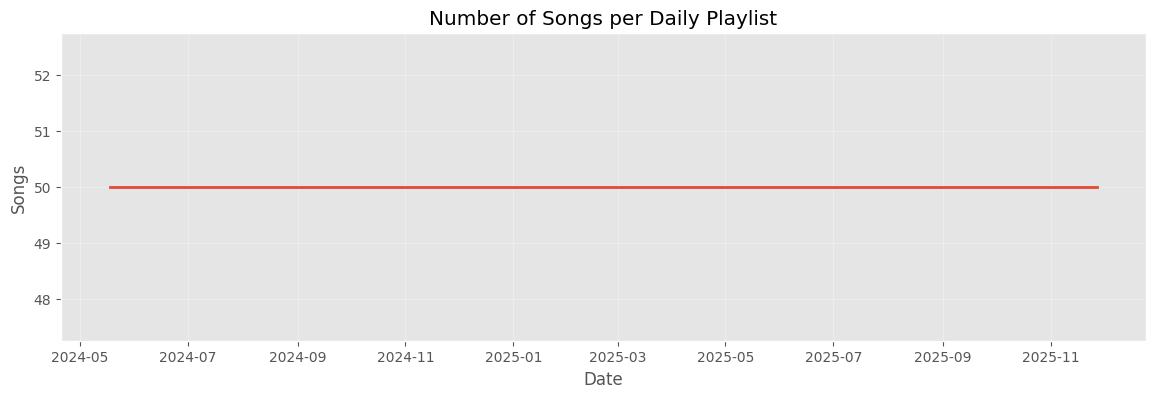

In [25]:
daily_counts = df_clean.groupby("date").size()

plt.figure(figsize=(14,4))

plt.plot(daily_counts.index,
         daily_counts.values,
         linewidth=2)

plt.title("Number of Songs per Daily Playlist")

plt.xlabel("Date")

plt.ylabel("Songs")

plt.grid(alpha=0.3)

plt.show()

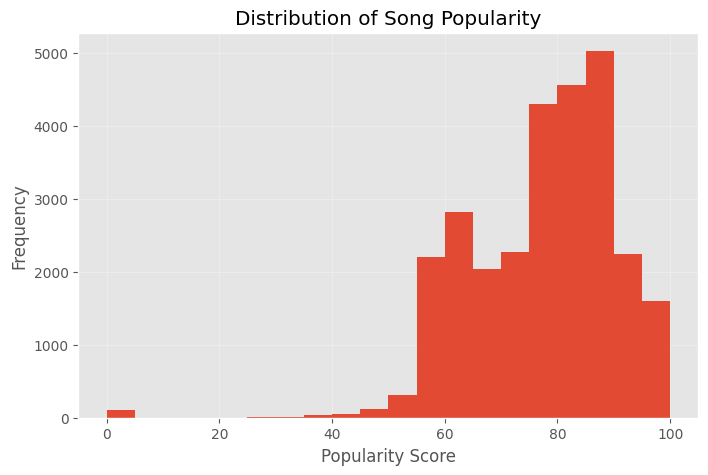

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["popularity"],
         bins=20)

plt.title("Distribution of Song Popularity")

plt.xlabel("Popularity Score")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

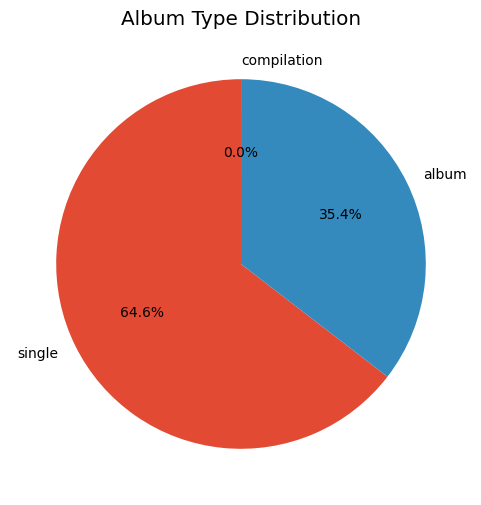

In [27]:
album_counts = df_clean["album_type"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(album_counts,
        labels=album_counts.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Album Type Distribution")

plt.show()

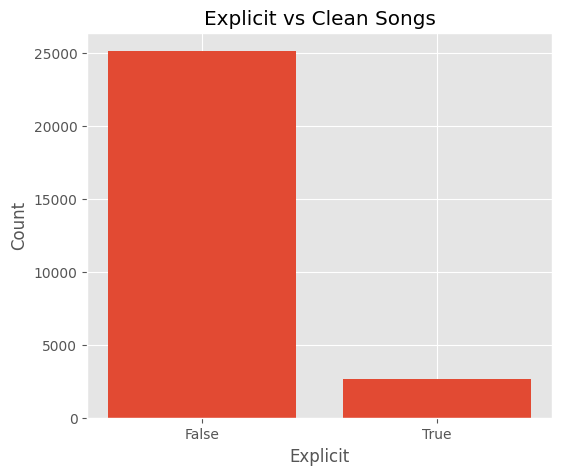

In [28]:
explicit_counts = df_clean["is_explicit"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    explicit_counts.index.astype(str),
    explicit_counts.values
)

plt.title("Explicit vs Clean Songs")

plt.xlabel("Explicit")

plt.ylabel("Count")

plt.show()

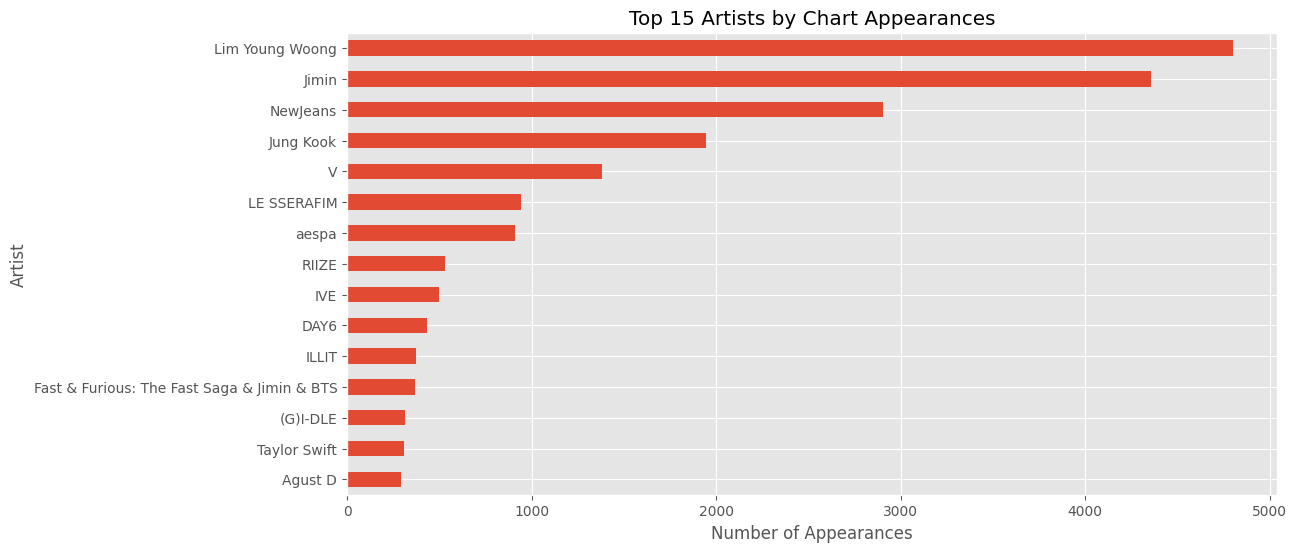

In [29]:
artist_counts = (
    df_clean["artist"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

artist_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Artists by Chart Appearances")
plt.xlabel("Number of Appearances")
plt.ylabel("Artist")

plt.show()

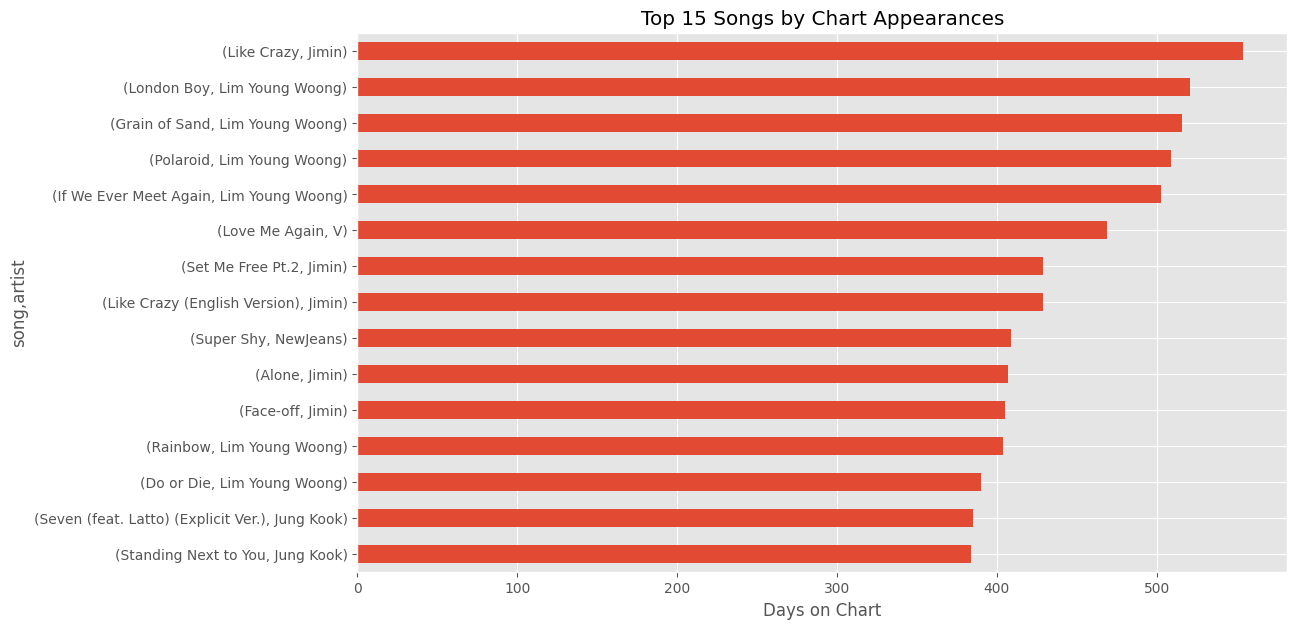

In [30]:
song_counts = (
    df_clean.groupby(["song","artist"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

song_counts.sort_values().plot(kind="barh")

plt.title("Top 15 Songs by Chart Appearances")
plt.xlabel("Days on Chart")

plt.show()

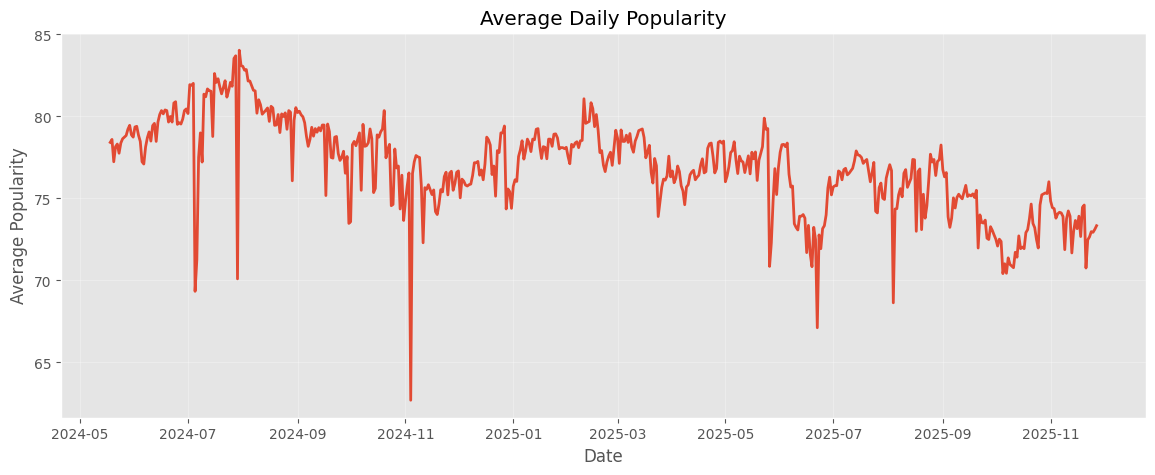

In [31]:
daily_popularity = (
    df_clean
    .groupby("date")["popularity"]
    .mean()
)

plt.figure(figsize=(14,5))

plt.plot(
    daily_popularity.index,
    daily_popularity.values,
    linewidth=2
)

plt.title("Average Daily Popularity")
plt.xlabel("Date")
plt.ylabel("Average Popularity")

plt.grid(alpha=0.3)

plt.show()

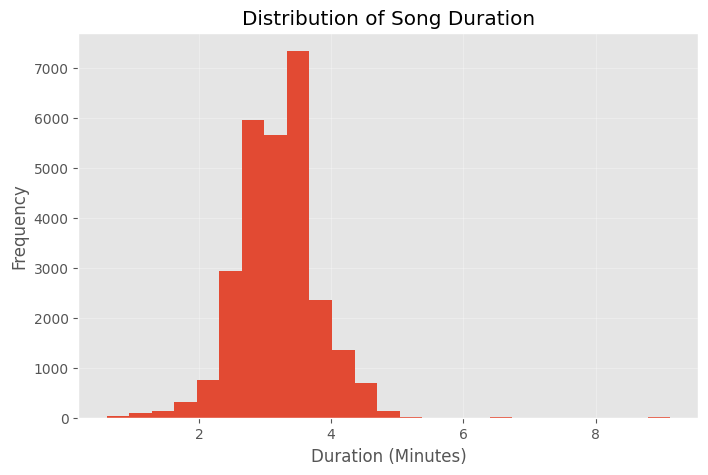

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    df_clean["duration_min"],
    bins=25
)

plt.title("Distribution of Song Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

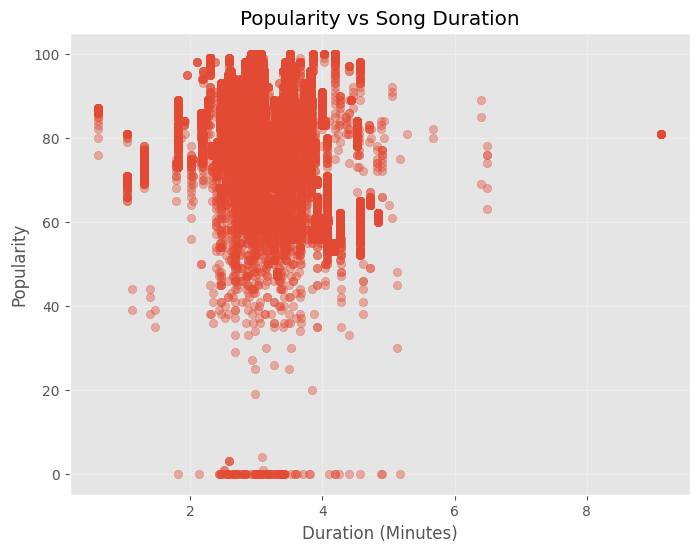

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_clean["duration_min"],
    df_clean["popularity"],
    alpha=0.4
)

plt.title("Popularity vs Song Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Popularity")

plt.grid(alpha=0.3)

plt.show()

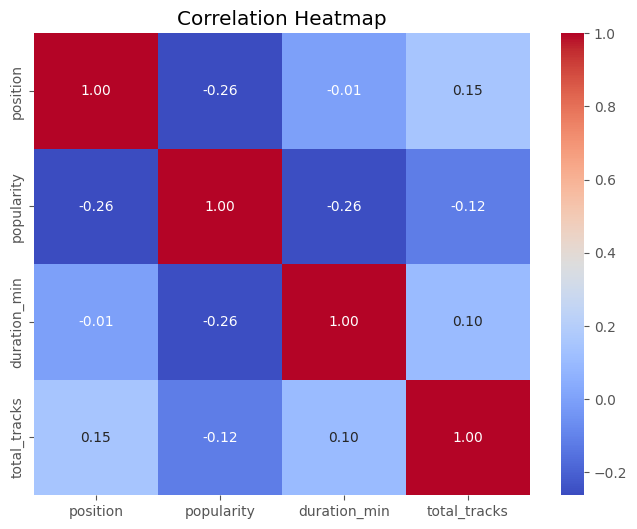

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_clean[
        [
            "position",
            "popularity",
            "duration_min",
            "total_tracks"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [35]:
song_stats = (
    df_clean.groupby("song_id")
    .agg(
        song=("song", "first"),
        artist=("artist", "first"),
        first_entry=("date", "min"),
        last_entry=("date", "max"),
        total_chart_days=("date", "count"),
        best_rank=("position", "min"),
        average_rank=("position", "mean"),
        average_popularity=("popularity", "mean"),
        max_popularity=("popularity", "max"),
        album_type=("album_type", "first"),
        total_tracks=("total_tracks", "first"),
        is_explicit=("is_explicit", "first"),
        duration_min=("duration_min", "first")
    )
    .reset_index()
)

song_stats.head()

,song_id,song,artist,first_entry,last_entry,total_chart_days,best_rank,average_rank,average_popularity,max_popularity,album_type,total_tracks,is_explicit,duration_min
0,1-800-hot-n-fun | le sserafim,1-800-hot-n-fun,LE SSERAFIM,2025-09-01,2025-09-08,8,26,37.750000,71.125000,75,single,5,False,2.890517
1,24yb (intro) | yanghongwon,24YB (Intro),YANGHONGWON,2025-05-26,2025-05-28,3,26,30.333333,41.333333,44,album,8,False,1.387333
2,3d (alternate ver.) | jung kook & jack harlow,3D (Alternate Ver.),Jung Kook & Jack Harlow,2024-10-02,2024-10-21,20,5,24.000000,68.050000,80,single,3,False,2.709083
3,3d (feat. jack harlow) (alternate ver.) | jung...,3D (feat. Jack Harlow) (Alternate Ver.),Jung Kook & Jack Harlow,2024-09-30,2024-10-01,2,4,4.000000,0.000000,0,single,3,False,2.709083
4,3d (feat. jack harlow) (instrumental) | jung k...,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,2024-09-30,2024-10-13,11,9,28.090909,50.818182,74,single,3,False,3.325833


In [36]:
song_stats.sort_values(
    by="total_chart_days",
    ascending=False
).head(10)

,song_id,song,artist,first_entry,last_entry,total_chart_days,best_rank,average_rank,average_popularity,max_popularity,album_type,total_tracks,is_explicit,duration_min
251,like crazy | jimin,Like Crazy,Jimin,2024-05-18,2025-11-27,554,1,6.680505,89.216606,96,single,6,False,3.537350
258,london boy | lim young woong,London Boy,Lim Young Woong,2024-05-18,2025-11-19,521,5,20.531670,64.205374,71,single,2,False,4.075000
171,grain of sand | lim young woong,Grain of Sand,Lim Young Woong,2024-06-08,2025-11-22,516,7,19.393411,65.155039,72,single,1,False,3.671817
342,polaroid | lim young woong,Polaroid,Lim Young Woong,2024-05-18,2025-10-11,509,10,24.499018,62.117878,68,single,2,False,3.440000
210,if we ever meet again | lim young woong,If We Ever Meet Again,Lim Young Woong,2024-05-18,2025-10-11,503,12,28.743539,60.139165,65,album,12,False,4.573100
268,love me again | v,Love Me Again,V,2024-08-13,2025-11-27,469,3,20.424307,88.528785,95,single,2,False,3.038217
248,like crazy (english version) | jimin,Like Crazy (English Version),Jimin,2024-05-18,2025-07-23,429,2,4.296037,82.193473,90,single,6,False,3.537550
375,set me free pt.2 | jimin,Set Me Free Pt.2,Jimin,2024-05-18,2025-07-23,429,4,6.256410,81.100233,87,single,1,True,3.348817
445,super shy | newjeans,Super Shy,NewJeans,2024-07-09,2025-09-19,409,1,25.337408,87.418093,95,single,2,False,2.577767
21,alone | jimin,Alone,Jimin,2024-05-18,2025-07-20,407,5,22.675676,77.985258,82,single,6,False,3.520833


In [37]:
song_stats.describe(include="all")

,song_id,song,artist,first_entry,last_entry,total_chart_days,best_rank,average_rank,average_popularity,max_popularity,album_type,total_tracks,is_explicit,duration_min
count,537,537,537,537,537,537.000000,537.000000,537.000000,537.000000,537.000000,537,537.000000,537,537.000000
unique,537,524,194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,2,NaN
top,한 페이지가 될 수 있게 | day6,Seven (feat. Latto) (Explicit Ver.),Jimin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,single,NaN,False,NaN
freq,1,3,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,319,NaN,439,NaN
mean,NaN,NaN,NaN,2025-01-14 08:00:00,2025-03-21 13:08:22.793296128,51.675978,24.858473,33.760521,67.737668,71.644320,NaN,7.204842,NaN,3.194476
min,NaN,NaN,NaN,2024-05-18 00:00:00,2024-05-18 00:00:00,1.000000,1.000000,1.000000,0.000000,0.000000,NaN,1.000000,NaN,0.603767
25%,NaN,NaN,NaN,2024-07-27 00:00:00,2024-10-20 00:00:00,3.000000,12.000000,27.651613,58.285714,62.000000,NaN,2.000000,NaN,2.790000
50%,NaN,NaN,NaN,2025-01-14 00:00:00,2025-03-24 00:00:00,11.000000,25.000000,35.058824,71.625000,76.000000,NaN,6.000000,NaN,3.092300
75%,NaN,NaN,NaN,2025-05-30 00:00:00,2025-09-06 00:00:00,60.000000,37.000000,42.400000,82.000000,85.000000,NaN,11.000000,NaN,3.503333
max,NaN,NaN,NaN,2025-11-25 00:00:00,2025-11-27 00:00:00,554.000000,50.000000,50.000000,99.750000,100.000000,NaN,40.000000,NaN,9.128883


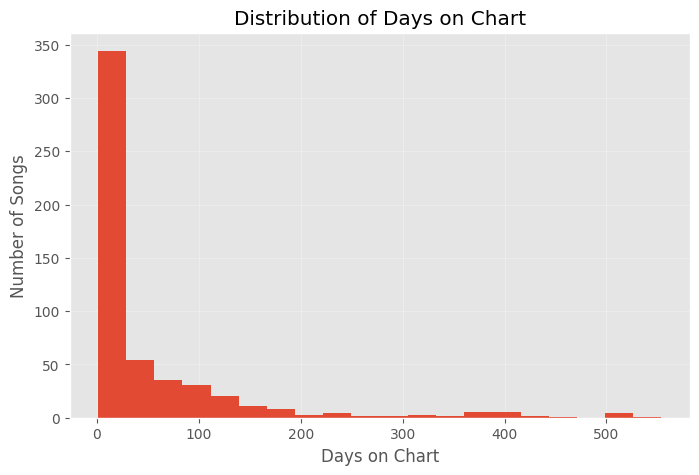

In [38]:
plt.figure(figsize=(8,5))

plt.hist(
    song_stats["total_chart_days"],
    bins=20
)

plt.title("Distribution of Days on Chart")
plt.xlabel("Days on Chart")
plt.ylabel("Number of Songs")

plt.grid(alpha=0.3)

plt.show()

In [39]:
f_clean = df_clean.sort_values(["song_id", "date"])

df_clean["day_gap"] = (
    df_clean.groupby("song_id")["date"]
    .diff()
    .dt.days
)

df_clean[["song", "artist", "date", "day_gap"]].head(20)

,song,artist,date,day_gap
0,Like Crazy,Jimin,2024-05-18,NaN
1,UNFORGIVEN (feat. Nile Rodgers),LE SSERAFIM,2024-05-18,NaN
2,Spicy,aespa,2024-05-18,NaN
3,I AM,IVE,2024-05-18,NaN
4,Queencard,(G)I-DLE,2024-05-18,NaN
5,Like Crazy (English Version),Jimin,2024-05-18,NaN
6,Set Me Free Pt.2,Jimin,2024-05-18,NaN
7,アイドル,YOASOBI,2024-05-18,NaN
8,Kitsch,IVE,2024-05-18,NaN
9,Cupid - Twin Ver.,FIFTY FIFTY,2024-05-18,NaN


In [40]:
df_clean["is_reentry"] = df_clean["day_gap"] > 1

reentries = df_clean[df_clean["is_reentry"]]

print("Total Re-entry Events:", len(reentries))

display(
    reentries[
        ["song", "artist", "date", "day_gap", "position", "popularity"]
    ].head(20)
)

Total Re-entry Events: 1074


,song,artist,date,day_gap,position,popularity
195,Kill Bill,SZA,2024-05-21,2.0,46,94
196,Teddy Bear,STAYC,2024-05-21,3.0,47,74
198,LOVE DIVE,IVE,2024-05-21,2.0,49,83
296,Love Always Run Away,Lim Young Woong,2024-05-23,5.0,47,58
342,VIBE (feat. Jimin of BTS),TAEYANG,2024-05-24,2.0,43,68
347,Interlude : Dive,Jimin,2024-05-24,4.0,48,77
399,Love Always Run Away,Lim Young Woong,2024-05-25,2.0,50,58
542,Like Crazy (Deep House Remix),Jimin,2024-05-28,8.0,43,73
543,Like Crazy (UK Garage Remix),Jimin,2024-05-28,8.0,44,72
544,Promise,Jimin,2024-05-28,8.0,45,77


In [47]:
reentry_summary = (
    df_clean.groupby("song_id", group_keys=False)
    .apply(
        lambda x: pd.Series({
            "song": x["song"].iloc[0],
            "artist": x["artist"].iloc[0],
            "reentry_count": (x["day_gap"] > 1).sum(),
            "max_gap": x.loc[x["day_gap"] > 1, "day_gap"].max(),
            "average_gap": x.loc[x["day_gap"] > 1, "day_gap"].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

reentry_summary = reentry_summary.fillna(0)

In [48]:
top_reentries = (
    reentry_summary
    .sort_values("reentry_count", ascending=False)
    .head(15)
)

top_reentries

,song_id,song,artist,reentry_count,max_gap,average_gap
328,"our blues, our life | lim young woong","Our Blues, Our Life",Lim Young Woong,31,20.0,3.967742
109,ditto | newjeans,Ditto,NewJeans,27,28.0,7.037037
10,a bientot | lim young woong,A bientot,Lim Young Woong,24,48.0,7.166667
313,new jeans | newjeans,New Jeans,NewJeans,23,63.0,9.260870
215,interlude : dive | jimin,Interlude : Dive,Jimin,21,7.0,3.095238
196,hype boy | newjeans,Hype Boy,NewJeans,21,50.0,10.190476
353,rainbow | lim young woong,Rainbow,Lim Young Woong,19,13.0,3.526316
128,eta | newjeans,ETA,NewJeans,18,77.0,8.277778
90,cruel summer | taylor swift,Cruel Summer,Taylor Swift,16,64.0,13.125000
415,somebody | jung kook,Somebody,Jung Kook,15,35.0,5.333333


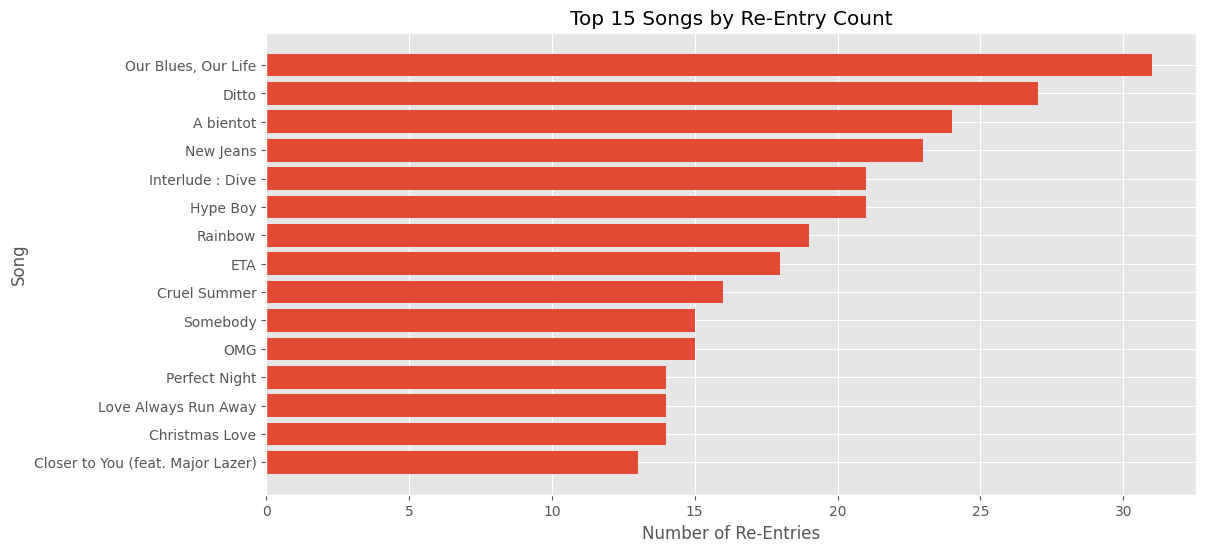

In [49]:
plt.figure(figsize=(12,6))

plt.barh(
    top_reentries["song"],
    top_reentries["reentry_count"]
)

plt.title("Top 15 Songs by Re-Entry Count")
plt.xlabel("Number of Re-Entries")
plt.ylabel("Song")

plt.gca().invert_yaxis()

plt.show()

In [51]:
columns_to_remove = [
    "reentry_count",
    "max_gap",
    "average_gap",
    "reentry_count_x",
    "max_gap_x",
    "average_gap_x",
    "reentry_count_y",
    "max_gap_y",
    "average_gap_y"
]

song_stats = song_stats.drop(
    columns=[col for col in columns_to_remove if col in song_stats.columns]
)

song_stats = song_stats.merge(
    reentry_summary[
        ["song_id", "reentry_count", "max_gap", "average_gap"]
    ],
    on="song_id",
    how="left"
)

song_stats[
    ["reentry_count", "max_gap", "average_gap"]
] = song_stats[
    ["reentry_count", "max_gap", "average_gap"]
].fillna(0)

display(song_stats.head())

,song_id,song,artist,first_entry,last_entry,total_chart_days,best_rank,average_rank,average_popularity,max_popularity,album_type,total_tracks,is_explicit,duration_min,reentry_count,max_gap,average_gap
0,1-800-hot-n-fun | le sserafim,1-800-hot-n-fun,LE SSERAFIM,2025-09-01,2025-09-08,8,26,37.750000,71.125000,75,single,5,False,2.890517,0,0.0,0.0
1,24yb (intro) | yanghongwon,24YB (Intro),YANGHONGWON,2025-05-26,2025-05-28,3,26,30.333333,41.333333,44,album,8,False,1.387333,0,0.0,0.0
2,3d (alternate ver.) | jung kook & jack harlow,3D (Alternate Ver.),Jung Kook & Jack Harlow,2024-10-02,2024-10-21,20,5,24.000000,68.050000,80,single,3,False,2.709083,0,0.0,0.0
3,3d (feat. jack harlow) (alternate ver.) | jung...,3D (feat. Jack Harlow) (Alternate Ver.),Jung Kook & Jack Harlow,2024-09-30,2024-10-01,2,4,4.000000,0.000000,0,single,3,False,2.709083,0,0.0,0.0
4,3d (feat. jack harlow) (instrumental) | jung k...,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,2024-09-30,2024-10-13,11,9,28.090909,50.818182,74,single,3,False,3.325833,1,4.0,4.0


In [52]:
print(song_stats.columns.tolist())

display(
    song_stats[
        [
            "song",
            "artist",
            "total_chart_days",
            "reentry_count",
            "max_gap",
            "average_gap"
        ]
    ].head(10)
)

['song_id', 'song', 'artist', 'first_entry', 'last_entry', 'total_chart_days', 'best_rank', 'average_rank', 'average_popularity', 'max_popularity', 'album_type', 'total_tracks', 'is_explicit', 'duration_min', 'reentry_count', 'max_gap', 'average_gap']


,song,artist,total_chart_days,reentry_count,max_gap,average_gap
0,1-800-hot-n-fun,LE SSERAFIM,8,0,0.0,0.0
1,24YB (Intro),YANGHONGWON,3,0,0.0,0.0
2,3D (Alternate Ver.),Jung Kook & Jack Harlow,20,0,0.0,0.0
3,3D (feat. Jack Harlow) (Alternate Ver.),Jung Kook & Jack Harlow,2,0,0.0,0.0
4,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,11,1,4.0,4.0
5,3D (feat. Jack Harlow) (MK Remix),Jung Kook & Jack Harlow & MK,4,0,0.0,0.0
6,3D (feat. Jack Harlow),Jung Kook,308,4,2.0,2.0
7,3D (feat. Jack Harlow),Jung Kook & Jack Harlow,112,0,0.0,0.0
8,3D (Justin Timberlake Remix),Jung Kook & Justin Timberlake,6,1,6.0,6.0
9,990 (Feat. Kim Ximya),Beenzino,5,0,0.0,0.0


In [53]:
df_clean["episode"] = (
    df_clean.groupby("song_id")["is_reentry"]
    .cumsum()
)

display(
    df_clean[
        ["song", "artist", "date", "day_gap", "is_reentry", "episode"]
    ].head(25)
)

,song,artist,date,day_gap,is_reentry,episode
0,Like Crazy,Jimin,2024-05-18,NaN,False,0
1,UNFORGIVEN (feat. Nile Rodgers),LE SSERAFIM,2024-05-18,NaN,False,0
2,Spicy,aespa,2024-05-18,NaN,False,0
3,I AM,IVE,2024-05-18,NaN,False,0
4,Queencard,(G)I-DLE,2024-05-18,NaN,False,0
5,Like Crazy (English Version),Jimin,2024-05-18,NaN,False,0
6,Set Me Free Pt.2,Jimin,2024-05-18,NaN,False,0
7,アイドル,YOASOBI,2024-05-18,NaN,False,0
8,Kitsch,IVE,2024-05-18,NaN,False,0
9,Cupid - Twin Ver.,FIFTY FIFTY,2024-05-18,NaN,False,0


In [54]:
episode_summary = (
    df_clean
    .groupby(["song_id", "episode"])
    .agg(
        song=("song", "first"),
        artist=("artist", "first"),

        comeback_date=("date", "min"),
        exit_date=("date", "max"),

        retention_days=("date", "count"),

        start_rank=("position", "first"),
        peak_rank=("position", "min"),

        start_popularity=("popularity", "first"),
        peak_popularity=("popularity", "max"),

        album_type=("album_type", "first"),
        is_explicit=("is_explicit", "first")
    )
    .reset_index()
)

episode_summary.head()

,song_id,episode,song,artist,comeback_date,exit_date,retention_days,start_rank,peak_rank,start_popularity,peak_popularity,album_type,is_explicit
0,1-800-hot-n-fun | le sserafim,0,1-800-hot-n-fun,LE SSERAFIM,2025-09-01,2025-09-08,8,26,26,64,75,single,False
1,24yb (intro) | yanghongwon,0,24YB (Intro),YANGHONGWON,2025-05-26,2025-05-28,3,26,26,38,44,album,False
2,3d (alternate ver.) | jung kook & jack harlow,0,3D (Alternate Ver.),Jung Kook & Jack Harlow,2024-10-02,2024-10-21,20,5,5,78,80,single,False
3,3d (feat. jack harlow) (alternate ver.) | jung...,0,3D (feat. Jack Harlow) (Alternate Ver.),Jung Kook & Jack Harlow,2024-09-30,2024-10-01,2,4,4,0,0,single,False
4,3d (feat. jack harlow) (instrumental) | jung k...,0,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,2024-09-30,2024-10-05,6,9,9,0,74,single,False


In [56]:
episode_summary["rank_improvement"] = (
    episode_summary["start_rank"]
    - episode_summary["peak_rank"]
)

episode_summary["popularity_gain"] = (
    episode_summary["peak_popularity"]
    - episode_summary["start_popularity"]
)

episode_summary["rank_decay"] = (
    episode_summary["peak_rank"]
    / episode_summary["retention_days"]
)

In [57]:
episode_summary.describe()

episode_summary.sort_values(
    "retention_days",
    ascending=False
).head(10)

,song_id,episode,song,artist,comeback_date,exit_date,retention_days,start_rank,peak_rank,start_popularity,peak_popularity,album_type,is_explicit,rank_improvement,popularity_gain,rank_decay
1080,polaroid | lim young woong,0,Polaroid,Lim Young Woong,2024-05-18,2025-03-13,301,22,10,64,68,single,False,12,4,0.033223
761,london boy | lim young woong,0,London Boy,Lim Young Woong,2024-05-18,2025-03-13,300,21,5,64,71,single,False,16,7,0.016667
725,like crazy (english version) | jimin,0,Like Crazy (English Version),Jimin,2024-05-18,2025-03-13,300,6,2,90,90,single,False,4,0,0.006667
1158,set me free pt.2 | jimin,0,Set Me Free Pt.2,Jimin,2024-05-18,2025-03-13,300,7,4,87,87,single,True,3,0,0.013333
412,face-off | jimin,0,Face-off,Jimin,2024-05-18,2025-03-13,300,28,5,81,83,single,True,23,2,0.016667
741,like crazy | jimin,0,Like Crazy,Jimin,2024-05-18,2025-03-13,300,1,1,93,96,single,False,0,3,0.003333
62,alone | jimin,0,Alone,Jimin,2024-05-18,2025-03-13,300,26,5,80,82,single,False,21,2,0.016667
499,grain of sand | lim young woong,0,Grain of Sand,Lim Young Woong,2024-06-08,2025-03-13,279,22,7,36,72,single,False,15,36,0.025090
1323,super shy | newjeans,0,Super Shy,NewJeans,2024-07-09,2025-03-13,248,4,1,0,95,single,False,3,95,0.004032
623,if we ever meet again | lim young woong,1,If We Ever Meet Again,Lim Young Woong,2024-07-30,2025-03-13,227,40,12,61,65,album,False,28,4,0.052863


In [58]:
from sklearn.preprocessing import MinMaxScaler

momentum_features = [
    "rank_improvement",
    "popularity_gain",
    "retention_days"
]

scaler = MinMaxScaler()

episode_summary[momentum_features] = scaler.fit_transform(
    episode_summary[momentum_features]
)

episode_summary.head()

,song_id,episode,song,artist,comeback_date,exit_date,retention_days,start_rank,peak_rank,start_popularity,peak_popularity,album_type,is_explicit,rank_improvement,popularity_gain,rank_decay
0,1-800-hot-n-fun | le sserafim,0,1-800-hot-n-fun,LE SSERAFIM,2025-09-01,2025-09-08,0.023333,26,26,64,75,single,False,0.0,0.11,3.250000
1,24yb (intro) | yanghongwon,0,24YB (Intro),YANGHONGWON,2025-05-26,2025-05-28,0.006667,26,26,38,44,album,False,0.0,0.06,8.666667
2,3d (alternate ver.) | jung kook & jack harlow,0,3D (Alternate Ver.),Jung Kook & Jack Harlow,2024-10-02,2024-10-21,0.063333,5,5,78,80,single,False,0.0,0.02,0.250000
3,3d (feat. jack harlow) (alternate ver.) | jung...,0,3D (feat. Jack Harlow) (Alternate Ver.),Jung Kook & Jack Harlow,2024-09-30,2024-10-01,0.003333,4,4,0,0,single,False,0.0,0.00,2.000000
4,3d (feat. jack harlow) (instrumental) | jung k...,0,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,2024-09-30,2024-10-05,0.016667,9,9,0,74,single,False,0.0,0.74,1.500000


In [59]:
episode_summary["momentum_score"] = (
    episode_summary["rank_improvement"] * 0.40
    + episode_summary["popularity_gain"] * 0.30
    + episode_summary["retention_days"] * 0.30
) * 100

episode_summary.head()

,song_id,episode,song,artist,comeback_date,exit_date,retention_days,start_rank,peak_rank,start_popularity,peak_popularity,album_type,is_explicit,rank_improvement,popularity_gain,rank_decay,momentum_score
0,1-800-hot-n-fun | le sserafim,0,1-800-hot-n-fun,LE SSERAFIM,2025-09-01,2025-09-08,0.023333,26,26,64,75,single,False,0.0,0.11,3.250000,4.0
1,24yb (intro) | yanghongwon,0,24YB (Intro),YANGHONGWON,2025-05-26,2025-05-28,0.006667,26,26,38,44,album,False,0.0,0.06,8.666667,2.0
2,3d (alternate ver.) | jung kook & jack harlow,0,3D (Alternate Ver.),Jung Kook & Jack Harlow,2024-10-02,2024-10-21,0.063333,5,5,78,80,single,False,0.0,0.02,0.250000,2.5
3,3d (feat. jack harlow) (alternate ver.) | jung...,0,3D (feat. Jack Harlow) (Alternate Ver.),Jung Kook & Jack Harlow,2024-09-30,2024-10-01,0.003333,4,4,0,0,single,False,0.0,0.00,2.000000,0.1
4,3d (feat. jack harlow) (instrumental) | jung k...,0,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,2024-09-30,2024-10-05,0.016667,9,9,0,74,single,False,0.0,0.74,1.500000,22.7


In [60]:
top_momentum = (
    episode_summary
    .sort_values("momentum_score", ascending=False)
    .head(15)
)

display(
    top_momentum[
        [
            "song",
            "artist",
            "momentum_score",
            "peak_rank",
            "retention_days"
        ]
    ]
)

,song,artist,momentum_score,peak_rank,retention_days
800,Love Lee,AKMU,72.300000,8,0.266667
294,Die With A Smile,Lady Gaga & Bruno Mars,68.492683,10,0.340000
327,Do or Die,Lim Young Woong,60.814634,6,0.516667
1409,To. X,TAEYEON,60.292683,12,0.306667
1323,Super Shy,NewJeans,56.126829,1,0.823333
499,Grain of Sand,Lim Young Woong,53.234146,7,0.926667
412,Face-off,Jimin,52.939024,5,0.996667
876,MEOW,MEOVV,51.546341,8,0.150000
623,If We Ever Meet Again,Lim Young Woong,51.117073,12,0.753333
62,Alone,Jimin,50.987805,5,0.996667


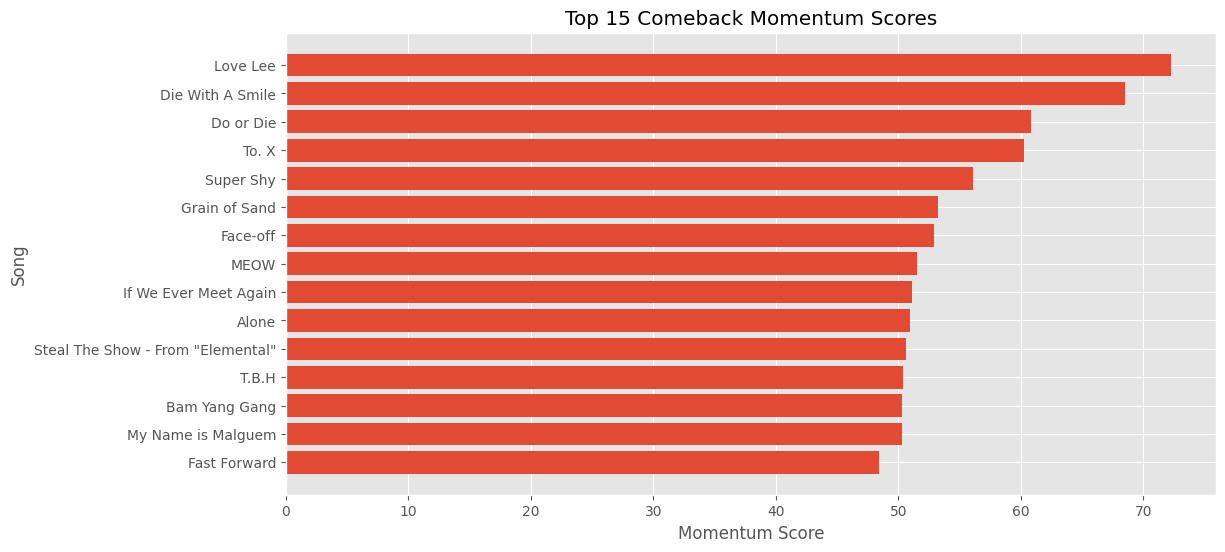

In [61]:
plt.figure(figsize=(12,6))

plt.barh(
    top_momentum["song"],
    top_momentum["momentum_score"]
)

plt.gca().invert_yaxis()

plt.xlabel("Momentum Score")
plt.ylabel("Song")

plt.title("Top 15 Comeback Momentum Scores")

plt.show()

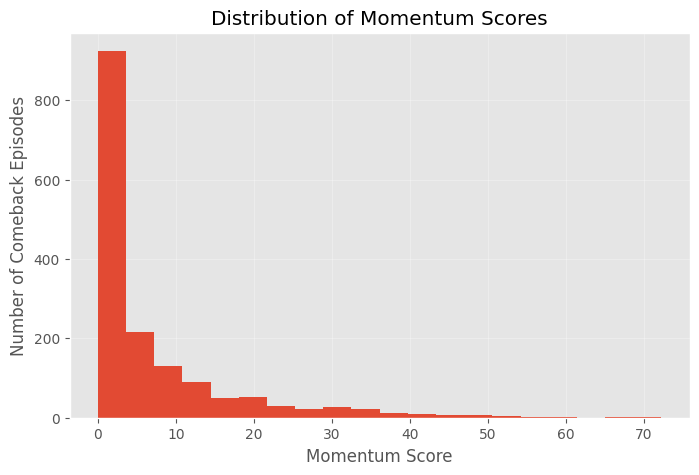

In [62]:
plt.figure(figsize=(8,5))

plt.hist(
    episode_summary["momentum_score"],
    bins=20
)

plt.title("Distribution of Momentum Scores")

plt.xlabel("Momentum Score")

plt.ylabel("Number of Comeback Episodes")

plt.grid(alpha=0.3)

plt.show()

In [63]:
song_momentum = (
    episode_summary
    .groupby("song_id")
    .agg(
        average_momentum=("momentum_score", "mean"),
        max_momentum=("momentum_score", "max"),
        comeback_events=("episode", "count")
    )
    .reset_index()
)

song_stats = song_stats.merge(
    song_momentum,
    on="song_id",
    how="left"
)

song_stats.head()

,song_id,song,artist,first_entry,last_entry,total_chart_days,best_rank,average_rank,average_popularity,max_popularity,album_type,total_tracks,is_explicit,duration_min,reentry_count,max_gap,average_gap,average_momentum,max_momentum,comeback_events
0,1-800-hot-n-fun | le sserafim,1-800-hot-n-fun,LE SSERAFIM,2025-09-01,2025-09-08,8,26,37.750000,71.125000,75,single,5,False,2.890517,0,0.0,0.0,4.000000,4.0,1
1,24yb (intro) | yanghongwon,24YB (Intro),YANGHONGWON,2025-05-26,2025-05-28,3,26,30.333333,41.333333,44,album,8,False,1.387333,0,0.0,0.0,2.000000,2.0,1
2,3d (alternate ver.) | jung kook & jack harlow,3D (Alternate Ver.),Jung Kook & Jack Harlow,2024-10-02,2024-10-21,20,5,24.000000,68.050000,80,single,3,False,2.709083,0,0.0,0.0,2.500000,2.5,1
3,3d (feat. jack harlow) (alternate ver.) | jung...,3D (feat. Jack Harlow) (Alternate Ver.),Jung Kook & Jack Harlow,2024-09-30,2024-10-01,2,4,4.000000,0.000000,0,single,3,False,2.709083,0,0.0,0.0,0.100000,0.1,1
4,3d (feat. jack harlow) (instrumental) | jung k...,3D (feat. Jack Harlow) (Instrumental),Jung Kook & Jack Harlow,2024-09-30,2024-10-13,11,9,28.090909,50.818182,74,single,3,False,3.325833,1,4.0,4.0,17.703659,22.7,2


In [64]:
episode_summary.rename(columns={
    "rank_improvement": "rank_improvement_norm",
    "popularity_gain": "popularity_gain_norm",
    "retention_days": "retention_days_norm"
}, inplace=True)

In [65]:
fandom = song_stats.copy()

fandom.head()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features = [
    "reentry_count",
    "average_momentum",
    "max_momentum",
    "total_chart_days"
]

fandom[features] = scaler.fit_transform(
    fandom[features]
)

In [66]:
fandom["fandom_score"] = (
    fandom["reentry_count"] * 0.40
    + fandom["average_momentum"] * 0.30
    + fandom["max_momentum"] * 0.20
    + fandom["total_chart_days"] * 0.10
) * 100

In [67]:
top_fandom = (
    fandom
    .sort_values("fandom_score", ascending=False)
    .head(20)
)

display(
    top_fandom[
        [
            "song",
            "artist",
            "fandom_score",
            "reentry_count",
            "average_momentum"
        ]
    ]
)

,song,artist,fandom_score,reentry_count,average_momentum
328,"Our Blues, Our Life",Lim Young Woong,58.683847,1.000000,0.045221
109,Ditto,NewJeans,51.820017,0.870968,0.054081
215,Interlude : Dive,Jimin,51.048582,0.677419,0.148052
106,Die With A Smile,Lady Gaga & Bruno Mars,50.791285,0.000000,1.000000
10,A bientot,Lim Young Woong,49.792859,0.774194,0.061246
313,New Jeans,NewJeans,47.669328,0.741935,0.055099
353,Rainbow,Lim Young Woong,45.571682,0.612903,0.080295
196,Hype Boy,NewJeans,41.140765,0.677419,0.054755
210,If We Ever Meet Again,Lim Young Woong,38.943238,0.258065,0.180088
128,ETA,NewJeans,38.938628,0.580645,0.100325


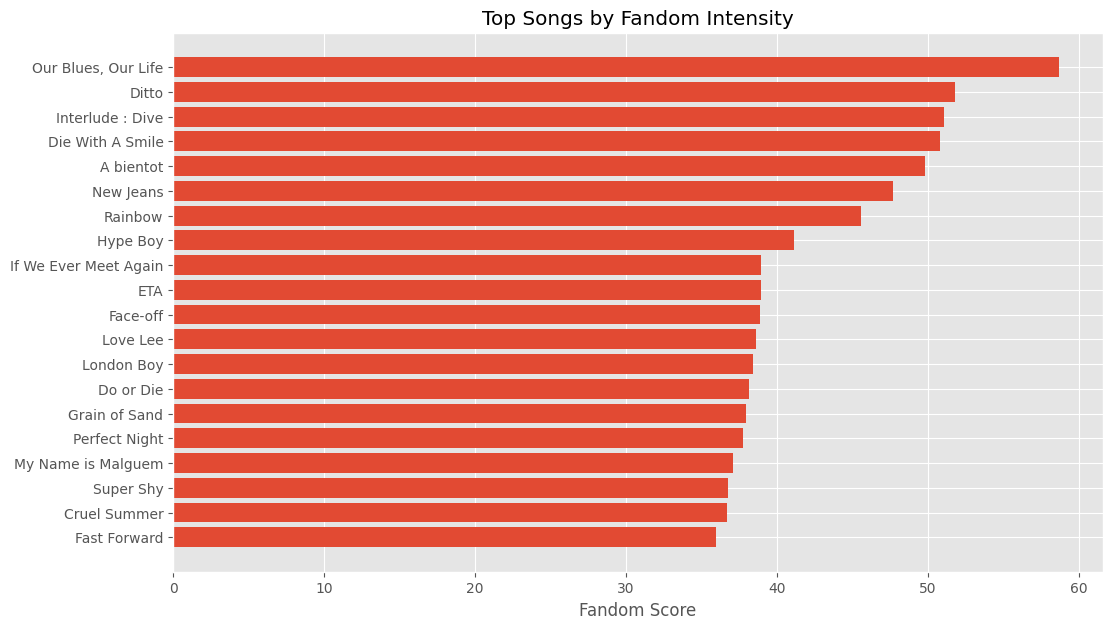

In [68]:
plt.figure(figsize=(12,7))

plt.barh(
    top_fandom["song"],
    top_fandom["fandom_score"]
)

plt.gca().invert_yaxis()

plt.title("Top Songs by Fandom Intensity")

plt.xlabel("Fandom Score")

plt.show()

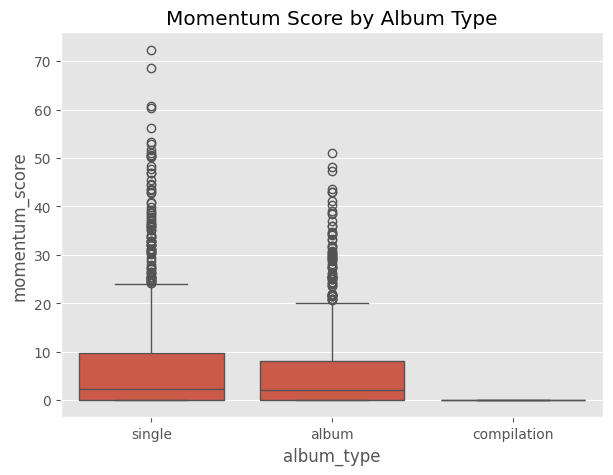

In [69]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=episode_summary,
    x="album_type",
    y="momentum_score"
)

plt.title("Momentum Score by Album Type")

plt.show()

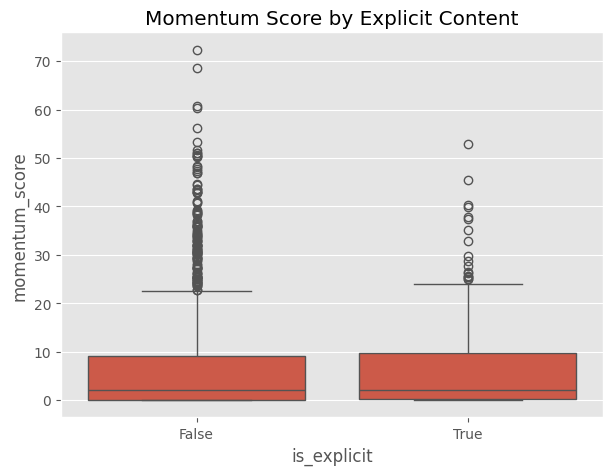

In [70]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=episode_summary,
    x="is_explicit",
    y="momentum_score"
)

plt.title("Momentum Score by Explicit Content")

plt.show()

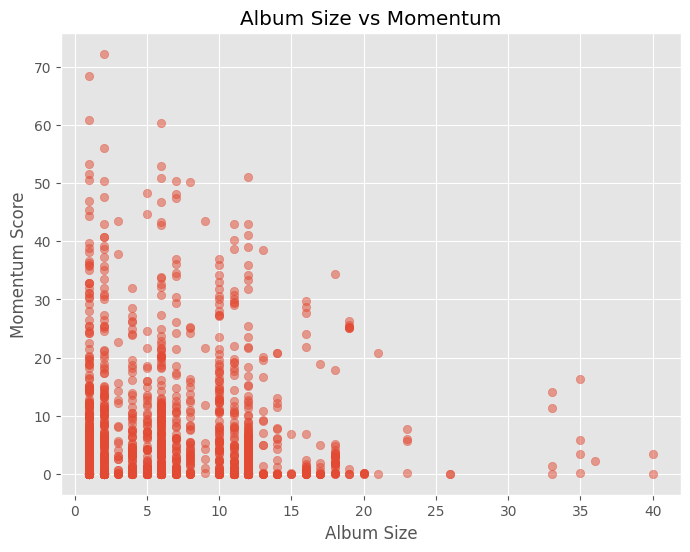

In [71]:
episode_summary = episode_summary.merge(
    song_stats[
        [
            "song_id",
            "total_tracks"
        ]
    ],
    on="song_id",
    how="left"
)

plt.figure(figsize=(8,6))

plt.scatter(
    episode_summary["total_tracks"],
    episode_summary["momentum_score"],
    alpha=0.5
)

plt.xlabel("Album Size")

plt.ylabel("Momentum Score")

plt.title("Album Size vs Momentum")

plt.show()

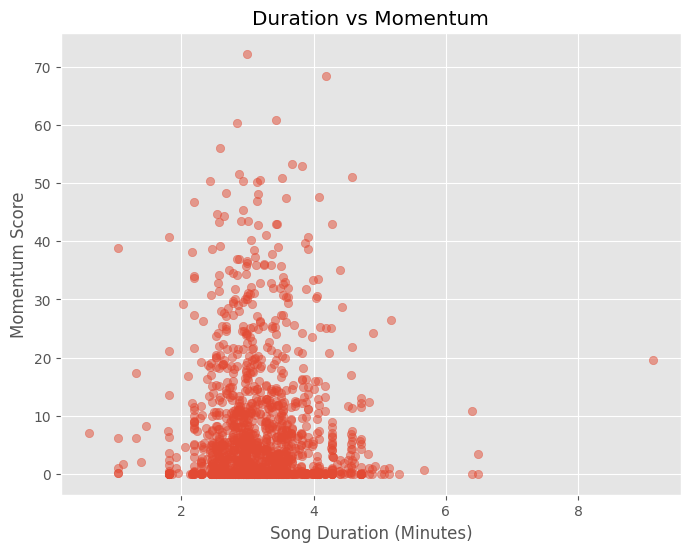

In [72]:
episode_summary = episode_summary.merge(
    song_stats[
        [
            "song_id",
            "duration_min"
        ]
    ],
    on="song_id",
    how="left"
)

plt.figure(figsize=(8,6))

plt.scatter(
    episode_summary["duration_min"],
    episode_summary["momentum_score"],
    alpha=0.5
)

plt.xlabel("Song Duration (Minutes)")

plt.ylabel("Momentum Score")

plt.title("Duration vs Momentum")

plt.show()